In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

from config.variables import (
    NUTRI_MACRO_VARS,
    NUTRI_MICRO_VARS,
    NUTRI_CFG_VARS,
    NUTRI_FG_VARS,
    # NUTRI_DI_VARS,
    # PERSONAL_VARS,
    AMOUNT_VARS,
    # get_cv_vars,
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

In [2]:
NUTRI_DI_VARS = [
    "HEI",
    "aMED",
    "DASH",  #'PDI_Quintile','hPDI_Quintile','mean_shannon_diversity_kcal','mean_mfad_jaccard_kcal',
    "mean_dds",
    "mean_berger_parker_kcal",
    "mean_simpson_diversity_kcal",
    "mean_gini_simpson_diversity_kcal",
    "mean_quantidd_kcal",
]

In [3]:
PERSONAL_VARS = [
    "age",
    "bmi",
    "bmr",
    "height",
    "weight",
    "cohabitants",
    "screen_hours",
    "stress_level",
    "defecate_quantity_per_day",
    "general_hunger_level",
    "morning_hunger_level",
    "evening_hunger_level",
    "mid_hunger_level",
]

In [4]:
meta = pd.read_csv("../../data/fay_meta_diets.csv", index_col=0)

cv_vars = [i for i in meta.columns if "CV_" in i and "eaten" in i]

In [5]:
def func_explained_var(data, factor_cols, target, label=None):
    data = data[data[factor_cols[0]].notna()]

    # Initialize and fit the linear regression model
    model = LinearRegression()
    model.fit(data[factor_cols], data[target])

    # Predict the outcomes
    y_pred = model.predict(data[factor_cols])

    # Calculate the variance explained (R²)
    r_squared = round(r2_score(data[target], y_pred), 3)

    if label:
        print(f"{label} Explained Variance (R²): {r_squared}")
    else:
        print(f"Explained Variance (R²): {r_squared}")
    return r_squared

In [8]:
target = "shannon_entropy"

nutri_macro_r2 = func_explained_var(
    meta, NUTRI_MACRO_VARS, target, label="nutri_vars_macro:\t"
)
personal_r2 = func_explained_var(meta, PERSONAL_VARS, target, label="personal_vars:\t")
func_explained_var(meta, AMOUNT_VARS, target, label="amount_vars:\t")
nutri_micro_r2 = func_explained_var(
    meta, NUTRI_MICRO_VARS, target, label="nutri_micro_vars:\t"
)
nutri_cfg_r2 = func_explained_var(
    meta, NUTRI_CFG_VARS, target, label="nutri_cfg_vars:\t"
)
nutri_fg_r2 = func_explained_var(meta, NUTRI_FG_VARS, target, label="nutri_fg_vars:\t")
nutri_DI_r2 = func_explained_var(meta, NUTRI_DI_VARS, target, label="nutri_DI_vars:\t")

nutri_all_r2 = func_explained_var(
    meta,
    NUTRI_MACRO_VARS
    + NUTRI_MICRO_VARS
    + NUTRI_FG_VARS
    + NUTRI_DI_VARS
    + cv_vars,  # +amount_vars+nutri_cfg_vars,
    target,
    label="Nutritional Only:\t",
)
all_r2 = func_explained_var(
    meta,
    NUTRI_MACRO_VARS
    + PERSONAL_VARS
    + NUTRI_MICRO_VARS
    + NUTRI_FG_VARS
    + NUTRI_DI_VARS
    + cv_vars,  # +amount_vars+nutri_cfg_vars,
    target,
    label="ALL:\t",
)

explained_variance_by_featset = pd.DataFrame(
    [
        ("All", all_r2, "green"),
        ("Personal", personal_r2, "gold"),
        ("All Nutritional", nutri_all_r2, "blue"),
        ("Micronutrients", nutri_micro_r2, "cyan"),
        ("Diet Indexes", nutri_DI_r2, "cyan"),
        ("Food Groups", nutri_fg_r2, "cyan"),
        ("Macronutrients", nutri_macro_r2, "cyan"),
    ],
    columns=["Feature Set", "Explained Variance (R2)", "color"],
)

explained_variance_by_featset = explained_variance_by_featset.sort_values(
    "Explained Variance (R2)", ascending=False
)

nutri_vars_macro:	 Explained Variance (R²): 0.048
personal_vars:	 Explained Variance (R²): 0.107
amount_vars:	 Explained Variance (R²): 0.002
nutri_micro_vars:	 Explained Variance (R²): 0.093
nutri_cfg_vars:	 Explained Variance (R²): 0.036
nutri_fg_vars:	 Explained Variance (R²): 0.067
nutri_DI_vars:	 Explained Variance (R²): 0.076
Nutritional Only:	 Explained Variance (R²): 0.205
ALL:	 Explained Variance (R²): 0.267


In [9]:
explained_variance_by_featset

,Feature Set,Explained Variance (R2),color
0,All,0.267,green
2,All Nutritional,0.205,blue
1,Personal,0.107,gold
3,Micronutrients,0.093,cyan
4,Diet Indexes,0.076,cyan
5,Food Groups,0.067,cyan
6,Macronutrients,0.048,cyan


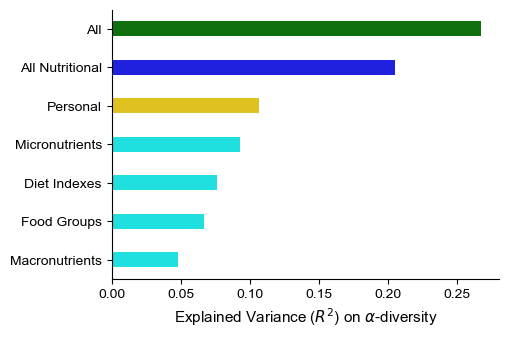

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(
    explained_variance_by_featset,
    y="Feature Set",
    x="Explained Variance (R2)",
    width=0.4,
    ax=ax,
    palette=explained_variance_by_featset["color"].values,
)

ax.set_ylabel("")
ax.set_xlabel(
    "Explained Variance ($R^2$) on $α$-diversity",
    fontsize=11,
    family="sans-serif",
    fontname="Arial",
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")
    label.set_fontsize(10)

sns.despine()

plt.savefig(
    "../../figures/gut_diversity_analysis/explained_variance.png",
    dpi=300,
    bbox_inches="tight",
)